# Batch normalization in a detector

This assignment examines how batch normalization changes the optimization of Faster R-CNN.

Ioffe and Szegedy (2015) proposed that batch normalization helps by reducing internal covariate shift: changes in a layer's input distribution as the preceding layers are updated. Santurkar et al. (2018) found that this distributional stability does not explain the optimization benefit. They instead reported a smoother loss landscape and gradients that better predict the next step. In this assignment, you will construct measurements related to both accounts, compare detectors trained with and without batch normalization, and decide whether this detector should retain the normalization layers.

The [batch normalization lecture](/aiml-common/lectures/optimization/batch-normalization)
covers the smoothness view. The batch normalization section of Google's
[Deep Learning Tuning Playbook](https://github.com/google-research/tuning_playbook#batch-normalization-implementation-details)
covers implementation details.

| Component | Points |
|---|---:|
| Three required runs complete and logged to your Trackio Space | 10 |
| Activation statistics | 25 |
| Loss spread and gradient predictiveness | 35 |
| Written answers, questions 1 and 2 | 30 |
| Total | 100 |

The experiment contains three required runs. Two establish the variation between repeated `bn` training runs, and the third provides a paired `bn` versus `no_bn` comparison at seed 0.

| Run | Arm | Seed | Purpose |
|---|---|---|---|
| 1 | BN | 0 | Baseline |
| 2 | BN | 1 | Repeated baseline for a rough measure of retraining variation |
| 3 | No BN | 0 | Paired comparison with run 1 |

A full run, including instrumentation, takes approximately 30 minutes on a Colab T4. Select a GPU runtime. You may complete the runs in separate sessions. Each run saves its log to `runs/<run name>.csv` after every epoch. A Colab session deletes its files when it ends, so download the `runs` folder after each run and upload it again in the next session.

In [1]:
%pip install -q trackio torchmetrics pycocotools

In [2]:
import math
import random
import time
from pathlib import Path

import numpy as np
import torch
import torchvision
import trackio
import matplotlib.pyplot as plt

## Your Hugging Face token

Trackio shows your training curves live in a Hugging Face Space. The code needs a Hugging Face token with write scope only to create that Space. In Colab, add the token to the Secrets panel, name it `HF_TOKEN`, and enable access for this notebook. Do not paste the token into a code cell because the submitted notebook and its outputs are visible to others.

Outside Colab, this cell does nothing. Instead, log in once from a terminal with `hf auth login`.

In [3]:
try:
    from google.colab import userdata
except ImportError:
    userdata = None  # not on Colab

if userdata is not None:
    from huggingface_hub import login

    login(token=userdata.get("HF_TOKEN"))

## Settings

Set `HF_USER` to your Hugging Face username. Do not change the other settings.

In [4]:
HF_USER = "your-hf-username"  # your Hugging Face username
TRACKIO_SPACE = f"{HF_USER}/detection-bn-trackio"  # Space for live curves
BASE_LR = 0.01  # same rate, every arm
EPOCHS = 4  # epochs per run
IMAGE_SIZE = 512  # image side in pixels
TRAIN_SPLIT = "train"  # split to train on
TRAIN_LIMIT = None  # None uses every image
VAL_LIMIT = None  # None uses every image
MAX_STEPS = None  # None trains full epochs
PRETRAINED_BACKBONE = True  # ImageNet backbone weights
CADENCE = dict(act_every=25, smooth_every=50)  # steps between measurements
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"  # GPU when available


## The data

<img src="https://raw.githubusercontent.com/pantelis/eng-ai-agents/main/notebooks/assignments/topics/object-detection/detection-instrumentation/images/sample-training-image.png" alt="A highway camera frame from the training split, taken in rain. Yellow boxes with class labels mark a big bus, three cars, a truck-l- and a truck-s- on a divided highway." width="560" />

*Training image 2529 with its labeled boxes.*

The images come from `Francesco/vehicles-q0x2v` on the Hugging Face Hub. This traffic-camera dataset comes from Roboflow-100. It contains about 2,600 training images, 458 validation images, and 966 test images. You will train on the train split and evaluate on the validation split. You will not use the test split.

The dataset defines 12 vehicle classes: big bus, big truck, bus-l-, bus-s-, car, mid truck, small bus, small truck, truck-l-, truck-m-, truck-s-, and truck-xl-. Several labels describe visually similar vehicles, which makes class-level errors likely.

Bounding boxes use COCO `[x, y, width, height]` coordinates. The loader converts them to the `[x1, y1, x2, y2]` representation required by torchvision and removes boxes less than one pixel wide or tall. Images without valid boxes remain in the dataset with an empty box tensor.

Roboflow-100 reserves class 0 for a dataset-level placeholder named `vehicles`. The annotated vehicle classes use labels 1 through 12. Because torchvision also reserves class 0 for the background, the labels already follow the required convention. Configure 13 model outputs and do not shift the labels.

In [5]:
"""Load the Roboflow-100 vehicles dataset as torchvision detection targets."""
import torch
from datasets import load_dataset
from torchvision.transforms.functional import pil_to_tensor

DATASET_ID = "Francesco/vehicles-q0x2v"
NUM_CLASSES = 13  # 12 vehicle classes, plus class 0, which torchvision uses for background


def coco_to_xyxy(bbox):
    """COCO boxes are [x, y, width, height]; torchvision wants [x1, y1, x2, y2]."""
    x, y, w, h = bbox
    return [x, y, x + w, y + h]


def to_target(example):
    """One dataset row to an image tensor in [0, 1] and a torchvision target dict."""
    image = pil_to_tensor(example["image"].convert("RGB")).float() / 255.0
    boxes, labels = [], []
    for bbox, label in zip(example["objects"]["bbox"], example["objects"]["category"]):
        x1, y1, x2, y2 = coco_to_xyxy(bbox)
        if x2 - x1 >= 1 and y2 - y1 >= 1:  # torchvision rejects boxes with no width or height
            boxes.append([x1, y1, x2, y2])
            labels.append(int(label))
    target = {
        "boxes": torch.tensor(boxes, dtype=torch.float32).reshape(-1, 4),
        "labels": torch.tensor(labels, dtype=torch.int64),
        "image_id": int(example["image_id"]),
    }
    return image, target


class DetectionSplit(torch.utils.data.Dataset):
    def __init__(self, hf_split):
        self.hf_split = hf_split

    def __len__(self):
        return len(self.hf_split)

    def __getitem__(self, i):
        return to_target(self.hf_split[i])


def load_split(name, limit=None):
    return load_dataset(DATASET_ID, split=f"{name}[:{limit}]" if limit else name)


def collate(batch):
    return tuple(zip(*batch))


def make_loader(hf_split, batch_size, shuffle, seed, num_workers=2):
    generator = torch.Generator().manual_seed(seed)
    return torch.utils.data.DataLoader(
        DetectionSplit(hf_split), batch_size=batch_size, shuffle=shuffle,
        generator=generator, collate_fn=collate, num_workers=num_workers,
    )


In [6]:
train_split = load_split(TRAIN_SPLIT, TRAIN_LIMIT)
val_split = load_split("validation", VAL_LIMIT)
CLASS_NAMES = train_split.features["objects"]["category"].feature.names
val_loader = make_loader(val_split, batch_size=4, shuffle=False, seed=0)


def train_loader(seed):
    """A shuffled training loader. The seed fixes the order of the batches."""
    return make_loader(train_split, batch_size=4, shuffle=True, seed=seed)


print(f"{len(train_split)} training images, {len(val_split)} validation images")

2634 training images, 458 validation images


## Detector configurations and measurement sites

The model is torchvision's Faster R-CNN v2 with a ResNet-50 backbone and a feature pyramid network (FPN). The configurations differ only in the normalization used by the FPN and box head. The required runs use `bn` and `no_bn`; `gn` is available for the optional extension.

| Part | `bn` | `no_bn` | `gn` |
|---|---|---|---|
| ResNet-50 body | frozen BN | frozen BN | frozen BN |
| FPN | `BatchNorm2d` | none | `GroupNorm(32, C)` |
| Box head (four 3x3 convs, one fc) | `BatchNorm2d` | none | `GroupNorm(32, C)` |
| RPN head | none | none | none |

Every configuration starts with the same ImageNet-pretrained backbone. The FPN, RPN, and box head are initialized from scratch. COCO detector weights are not used because their parameterization does not match the `no_bn` configuration. Runs 1 and 3 use the same seed so that their newly initialized layers and batch order begin from the same random state.

The first three configurations use `FrozenBatchNorm2d` in the backbone. Freezing these layers preserves the statistics learned during ImageNet pretraining and is common in detection systems trained with small image batches. Applying the same frozen backbone to `bn` and `no_bn` isolates the experimental change to the FPN and box head.

The relevant sample axes differ across the network. `BatchNorm2d` in the FPN estimates each channel's statistics over the image and spatial dimensions, $N \times H \times W$, at each pyramid level. The box head operates on sampled regions: 512 RoIs per image yield approximately 2,048 region samples for a four-image batch, again with spatial positions contributing to the estimate. These counts are not independent sample sizes because nearby pixels and proposals are correlated.

The diagram identifies the components used in the experiment. Green blocks change between `bn` and `no_bn` and are instrumented before normalization and at the block output. The other blocks are identical in the two required configurations.

<img src="https://raw.githubusercontent.com/pantelis/eng-ai-agents/main/notebooks/assignments/topics/object-detection/detection-instrumentation/images/faster-rcnn-bn-arms.svg" alt="Faster R-CNN data flow. Input images enter the ResNet-50 backbone (stem and stages C2 to C5, frozen batch normalization). The backbone feeds the feature pyramid network: four inner blocks (1x1 conv, optional BN, measured), the top-down pathway with lateral addition, and four output blocks (3x3 conv, optional BN, measured). The pyramid features P2 to P5 go to the RPN head and to multi-scale RoIAlign. The RPN head produces the RPN losses and region proposals, and the proposals also go to RoIAlign. RoIAlign feeds the RoI box head: four blocks (3x3 conv, optional BN, ReLU, measured), a fully connected layer, and the class and box predictors, which give the RoI losses and the detections. The measured blocks are the only parts that differ between the bn and no_bn arms." width="720" />

*Faster R-CNN with the blocks that differ between the `bn` and `no_bn` arms outlined in green.*

*Editable Mermaid source: [`images/faster-rcnn-bn-arms.mermaid.md`](https://github.com/pantelis/eng-ai-agents/blob/main/notebooks/assignments/topics/object-detection/detection-instrumentation/images/faster-rcnn-bn-arms.mermaid.md)*

In [7]:
"""Faster R-CNN v2 built with BN, no normalization, or GroupNorm in its heads."""
from torch import nn
from torchvision.models import ResNet50_Weights, resnet50
from torchvision.models.detection.backbone_utils import _resnet_fpn_extractor
from torchvision.models.detection.faster_rcnn import FasterRCNN, FastRCNNConvFCHead, _default_anchorgen
from torchvision.models.detection.rpn import RPNHead
from torchvision.ops import FrozenBatchNorm2d

ARMS = ("bn", "no_bn", "gn")


def _head_norm(arm):
    """The normalization layer used in the FPN and the box head."""
    if arm == "bn":
        return nn.BatchNorm2d
    if arm == "no_bn":
        return None
    if arm == "gn":
        return lambda channels: nn.GroupNorm(32, channels)
    raise ValueError(f"unknown arm {arm!r}, expected one of {ARMS}")


def build_model(arm, image_size=512, pretrained_backbone=True):
    head_norm = _head_norm(arm)
    weights = ResNet50_Weights.IMAGENET1K_V2 if pretrained_backbone else None
    body = resnet50(weights=weights, norm_layer=FrozenBatchNorm2d)
    backbone = _resnet_fpn_extractor(body, trainable_layers=3, norm_layer=head_norm)
    anchors = _default_anchorgen()
    rpn_head = RPNHead(backbone.out_channels, anchors.num_anchors_per_location()[0], conv_depth=2)
    box_head = FastRCNNConvFCHead((backbone.out_channels, 7, 7), [256, 256, 256, 256], [1024], norm_layer=head_norm)
    return FasterRCNN(
        backbone, num_classes=NUM_CLASSES, rpn_anchor_generator=anchors, rpn_head=rpn_head,
        box_head=box_head, min_size=image_size, max_size=image_size,
    )


In [8]:
NORM_TYPES = (nn.BatchNorm2d, FrozenBatchNorm2d, nn.GroupNorm)
PARTS = {"body": "backbone.body", "fpn": "backbone.fpn", "rpn": "rpn", "box_head": "roi_heads.box_head"}

for arm in ("bn", "no_bn"):
    model = build_model(arm, IMAGE_SIZE, pretrained_backbone=False)
    counts = {part: 0 for part in PARTS}
    for name, module in model.named_modules():
        if isinstance(module, NORM_TYPES):
            for part, prefix in PARTS.items():
                if name.startswith(prefix + "."):
                    counts[part] += 1
    print(arm, counts)
del model

bn {'body': 53, 'fpn': 8, 'rpn': 0, 'box_head': 4}
no_bn {'body': 53, 'fpn': 0, 'rpn': 0, 'box_head': 0}


## Measurements during training

Several instruments require additional forward and backward passes. Those passes must not alter the training trajectory, and repeated evaluations within one measurement must use the same stochastic choices. The implementation enforces three conditions, although proposal changes remain a source of noise.

First, control the random state. Faster R-CNN samples anchors and RoIs in training mode. Two passes that use different samples may produce different losses at identical weights. Run every pass within a measurement under `frozen_rng(seed)`, which resets the seed for the pass and restores the training loop's random state afterward.

Second, restore model state. Some instruments temporarily perturb the weights. `preserved_state(model)` saves and restores every parameter and buffer, including BN running statistics. The optimizer state is not modified by these measurement passes.

Third, retain training mode. The measurements concern the training objective, so BN must use batch statistics just as it does during an optimization step.

Fixed randomness does not fix the proposals themselves. RPN proposals depend on the current weights, so a perturbation can change the retained RoIs. Treat the resulting variation as measurement noise.


In [9]:
"""Utilities that keep extra measurement passes comparable and side-effect free."""
import contextlib
import torch


def trainable_params(model):
    return [p for p in model.parameters() if p.requires_grad]


@contextlib.contextmanager
def frozen_rng(seed):
    """Same random anchor and RoI sampling on every pass, and the training RNG left as it was."""
    devices = [torch.cuda.current_device()] if torch.cuda.is_available() else []
    with torch.random.fork_rng(devices=devices):
        torch.manual_seed(seed)
        yield


@contextlib.contextmanager
def preserved_state(model):
    """Restore every weight and buffer afterwards, including BatchNorm running statistics."""
    saved = {k: v.detach().clone() for k, v in model.state_dict().items()}
    try:
        yield
    finally:
        model.load_state_dict(saved)


## Part 1: the instruments

Implement `Instrumentation`, which the training loop calls at fixed points during each step. It returns scalar measurements that the loop adds to the run log and sends to Trackio. In the definitions below, $w$ denotes all trainable parameters, $L$ is the sum of the four detection losses, $g = \nabla L(w)$ is the gradient on the current batch, and $\eta$ is the current learning rate.


### Activation statistics

Record activation statistics at 12 sites: four FPN inner blocks, four FPN output blocks, and four convolutional blocks in the box head. Each block contains a convolution, followed by normalization in the `bn` configuration and by an activation when the architecture specifies one. The blocks are `model.backbone.fpn.inner_blocks[i]`, `model.backbone.fpn.layer_blocks[i]`, and `model.roi_heads.box_head[i]`; the convolution is element 0. Attach hooks to the same locations in every configuration and record only when `step % act_every == 0`.

At each site $\ell$, record the mean and standard deviation at two points:

$$
\mu_\ell = \operatorname{mean}(z_\ell), \quad \sigma_\ell = \operatorname{std}(z_\ell), \qquad
\mu^{\text{out}}_\ell = \operatorname{mean}(a_\ell), \quad \sigma^{\text{out}}_\ell = \operatorname{std}(a_\ell)
$$

Here, $z_\ell$ is the conv output before normalization, and $a_\ell$ is the output of the complete block. Compute both over the whole batch.

The two locations answer different questions. The convolution output measures the scale before normalization. Apart from the stabilizing term $\epsilon$ and any regularization, scaling weights immediately before BN has little effect on the normalized output; those weight norms may therefore grow while training remains stable. The complete block output is passed downstream and is the closer proxy for the layer inputs discussed in the internal-covariate-shift account.

These four statistics record only the first two moments, not the full activation distribution. A stable `act_out_std` in the `bn` configuration is also partly guaranteed by the operation being tested. Treat the measurements as limited evidence: compare both pre-normalization and block-output statistics, examine their trajectories rather than a single value, and avoid claiming that stable moments prove the absence of distribution shift.

### Loss along the gradient

Evaluate the loss after taking gradient steps of several lengths:

$$
\Delta L = \max_{t \in T} L(w - t \eta g) - \min_{t \in T} L(w - t \eta g), \qquad T = \{0, 0.25, 0.5, 1, 1.5, 2\}
$$

The spread summarizes how much the loss varies over the sampled segment. It is affected by both slope and curvature, so it is not a curvature estimate by itself. Santurkar et al. (2018) use this diagnostic in their analysis of effective smoothness. Measure it on the current batch every `smooth_every` steps and interpret it together with gradient norm and gradient predictiveness.

### Gradient predictiveness

Compare the gradient before and after one full step:

$$
\lVert \nabla L(w) - \nabla L(w - \eta g) \rVert_2
$$

A small value means that the gradient at the starting point is close to the gradient at the proposed destination. Santurkar et al. call this gradient predictiveness and report smaller changes with BN. Because the raw difference also depends on gradient scale, compare `smooth/grad_pred` with `smooth/grad_norm`. Measure both on the same batch and at the same steps as the loss spread.

### Metric keys

Use these keys exactly because the run log and `plot_metric` depend on them.

| Key | Set in | Cadence |
|---|---|---|
| `loss/<loss name>`, `loss/total` | `after_forward` | every step |
| `act_mean/<site>`, `act_std/<site>` | forward hooks on the convs | every `act_every` steps |
| `act_out_mean/<site>`, `act_out_std/<site>` | forward hooks on the blocks | every `act_every` steps |
| `smooth/loss_spread`, `smooth/grad_pred`, `smooth/grad_norm` | `periodic` | every `smooth_every` steps |

The sites are `fpn.inner0` to `fpn.inner3`, `fpn.layer0` to `fpn.layer3`, and `box_head.conv0` to `box_head.conv3`. The loop also records `lr`.

Implement `smoothness` first, then implement the `Instrumentation` object that calls it.

In [10]:
def smoothness(loss_fn, params, lr, ts=(0.25, 0.5, 1.0, 1.5, 2.0), seed=0):
    """Loss spread along the gradient step, and how much the gradient changes over one step.

    The loss spread covers the loss at w itself (t = 0) as well as the loss at each of the ts points.
    loss_fn() runs a forward pass on the current batch and returns the loss. Call it inside frozen_rng(seed)
    every time. Return a dict with the keys "loss_spread", "grad_pred" and "grad_norm". Put params back where
    you found them before you return.
    """

    params = list(params)

    # Save the original parameter values
    original_params = [p.detach().clone() for p in params]

    try:
        # -------------------------------------------------
        # 1. Loss and gradient at the starting weights w
        # -------------------------------------------------
        with frozen_rng(seed):
            loss0 = loss_fn()

        grads0 = torch.autograd.grad(loss0, params)
        grads0 = [g.detach() for g in grads0]

        # ||g||_2
        grad_norm = torch.sqrt(
            sum((g ** 2).sum() for g in grads0)
        )

        # Include t = 0 in the loss-spread calculation
        losses = [loss0.detach()]

        grads1 = None

        # -------------------------------------------------
        # 2. Evaluate loss at w - t * lr * g
        # -------------------------------------------------
        for t in ts:

            with torch.no_grad():
                for p, p0, g in zip(params, original_params, grads0):
                    p.copy_(p0 - t * lr * g)

            with frozen_rng(seed):
                loss_t = loss_fn()

            losses.append(loss_t.detach())

            # Gradient after one full step
            if t == 1.0:
                grads1 = torch.autograd.grad(loss_t, params)
                grads1 = [g.detach() for g in grads1]

        # -------------------------------------------------
        # 3. Loss spread
        # -------------------------------------------------
        losses = torch.stack(losses)

        loss_spread = losses.max() - losses.min()

        # -------------------------------------------------
        # 4. Gradient predictiveness
        # ||grad(w) - grad(w - lr*g)||_2
        # -------------------------------------------------
        grad_pred = torch.sqrt(
            sum(
                ((g0 - g1) ** 2).sum()
                for g0, g1 in zip(grads0, grads1)
            )
        )

        return {
            "loss_spread": loss_spread.item(),
            "grad_pred": grad_pred.item(),
            "grad_norm": grad_norm.item(),
        }

    finally:
        # Restore original weights
        with torch.no_grad():
            for p, p0 in zip(params, original_params):
                p.copy_(p0)


In [11]:
class Instrumentation:
    """Collects the scalars for one training run. The training loop calls it at fixed points in every step."""

    def __init__(self, model, act_every=25, smooth_every=50, seed=0):
        """Called once, before training. Store the settings, and hook the convs and the blocks around them."""

        self.model = model
        self.act_every = act_every
        self.smooth_every = smooth_every
        self.seed = seed

        self.scalars = {}
        self.record_activations = False
        self.hooks = []

        # Hook for convolution output BEFORE normalization
        def make_conv_hook(site):
            def hook(module, inputs, output):
                if not self.record_activations:
                    return

                x = output.detach()

                self.scalars[f"act_mean/{site}"] = x.mean().item()
                self.scalars[f"act_std/{site}"] = x.std().item()

            return hook

        # Hook for output of the COMPLETE block
        def make_block_hook(site):
            def hook(module, inputs, output):
                if not self.record_activations:
                    return

                x = output.detach()

                self.scalars[f"act_out_mean/{site}"] = x.mean().item()
                self.scalars[f"act_out_std/{site}"] = x.std().item()

            return hook

        # Attach both hooks to one block
        def attach(site, block):
            # Element 0 is the convolution
            conv = block[0]

            self.hooks.append(
                conv.register_forward_hook(make_conv_hook(site))
            )

            self.hooks.append(
                block.register_forward_hook(make_block_hook(site))
            )

        # ---------------------------------------
        # Four FPN inner blocks
        # ---------------------------------------
        for i in range(4):
            attach(
                f"fpn.inner{i}",
                model.backbone.fpn.inner_blocks[i]
            )

        # ---------------------------------------
        # Four FPN output/layer blocks
        # ---------------------------------------
        for i in range(4):
            attach(
                f"fpn.layer{i}",
                model.backbone.fpn.layer_blocks[i]
            )

        # ---------------------------------------
        # Four convolution blocks in box head
        # ---------------------------------------
        for i in range(4):
            attach(
                f"box_head.conv{i}",
                model.roi_heads.box_head[i]
            )

    def before_forward(self, step):
        """Called before the forward pass. Decide whether this step records activations."""

        self.record_activations = (step % self.act_every == 0)

    def after_forward(self, step, loss_dict):
        """Called after the forward pass, with the four losses the model returned.

        Stop recording activations here. Otherwise the extra passes in periodic and the evaluation passes
        overwrite the values from the training forward.
        """

        # Stop activation hooks from recording extra passes
        self.record_activations = False

        total_loss = 0.0

        for name, loss in loss_dict.items():
            value = loss.detach().item()

            self.scalars[f"loss/{name}"] = value
            total_loss += value

        self.scalars["loss/total"] = total_loss

    def periodic(self, step, model, images, targets, lr):
        """Called at the end of every step. Run the extra passes on the steps where they are due."""

        if step % self.smooth_every != 0:
            return

        def loss_fn():
            loss_dict = model(images, targets)
            return sum(loss_dict.values())

        params = trainable_params(model)

        # Restore weights AND buffers such as BN running stats afterward
        with preserved_state(model):

            results = smoothness(
                loss_fn=loss_fn,
                params=params,
                lr=lr,
                seed=self.seed,
            )

        self.scalars["smooth/loss_spread"] = results["loss_spread"]
        self.scalars["smooth/grad_pred"] = results["grad_pred"]
        self.scalars["smooth/grad_norm"] = results["grad_norm"]

    def pop_scalars(self):
        """Called once per step. Return this step's scalars and start an empty dict for the next step."""

        results = self.scalars
        self.scalars = {}

        return results

    def close(self):
        """Called when the run ends. Remove your hooks."""

        for hook in self.hooks:
            hook.remove()

        self.hooks = []


## The training loop

The provided training loop sets the warmup learning rate at the beginning of each step. It calls `before_forward`, performs the forward pass, sends the returned losses to `after_forward`, and applies the optimizer update. It then calls `periodic` for measurements that require extra passes. `pop_scalars` returns the completed measurements, which the loop adds to the run log and sends to Trackio.

The run log has one row per value, with the columns `run`, `step`, `epoch`, `metric`, `group` and `value`. A key such as `smooth/grad_pred` becomes `metric = "smooth"` and `group = "grad_pred"`. A key without a slash, such as `lr`, gets an empty group. At the end of each epoch, the loop evaluates average precision on the validation split and logs it under the metric `ap`, then saves the log to `runs/<run name>.csv`. If the total loss becomes nonfinite, the loop logs the step as `diverged_at_step` and stops. That incomplete epoch has no evaluation.

If you have not implemented `Instrumentation.pop_scalars`, `run` reports the missing method and does not train. Any other missing method stops the run with an error.

In [12]:
"""The run log you are given: one row per logged value, saved as runs/<run>.csv."""
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

COLUMNS = ("run", "step", "epoch", "metric", "group", "value")
LOG_DIR = Path("runs")


class RunLog:
    """Collects the scalars of one run. A key "metric/group" is split in two; a key without a slash has group ""."""

    def __init__(self, root, run):
        self.path = Path(root) / f"{run}.csv"
        self.run = run
        self.rows = []

    def add(self, step, epoch, scalars):
        for key, value in scalars.items():
            metric, _, group = key.partition("/")
            self.rows.append((self.run, step, epoch, metric, group, float(value)))

    def frame(self):
        return pd.DataFrame(self.rows, columns=list(COLUMNS))

    def save(self):
        self.path.parent.mkdir(parents=True, exist_ok=True)
        self.frame().to_csv(self.path, index=False)


def load_runs(root=LOG_DIR):
    """Every saved run log under root, stacked into one frame."""
    frames = [pd.read_csv(path, keep_default_na=False) for path in sorted(Path(root).glob("*.csv"))]
    if not frames:
        return pd.DataFrame(columns=list(COLUMNS))
    return pd.concat(frames, ignore_index=True)


def final_ap(root=LOG_DIR):
    """AP at the last evaluated epoch of each run, one row per run."""
    ap = load_runs(root).query("metric == 'ap'")
    if ap.empty:
        print("No AP logged yet. A run logs AP at the end of each epoch.")
        return None
    last = ap[ap["epoch"] == ap.groupby("run")["epoch"].transform("max")]
    table = last.pivot_table(index="run", columns="group", values="value")
    table.insert(0, "epoch", last.groupby("run")["epoch"].max())
    table.columns.name = None
    return table


def plot_metric(metric, group="", runs=None, root=LOG_DIR, show=True):
    """One line per run for one metric and group, for example plot_metric("smooth", "grad_pred")."""
    frame = load_runs(root).query("metric == @metric and group == @group")
    if runs is not None:
        frame = frame[frame["run"].isin(runs)]
    if frame.empty:
        print(f"No values logged yet for metric={metric!r}, group={group!r}.")
        return None
    fig, ax = plt.subplots(figsize=(6, 4))
    for name, rows in frame.groupby("run"):
        ax.plot(rows["step"], rows["value"], label=name)
    ax.set_xlabel("step")
    ax.set_ylabel(f"{metric}/{group}" if group else metric)
    ax.legend()
    if show:
        plt.show()
        return None
    return ax


In [13]:
"""The training loop you are given. It calls your Instrumentation at fixed points and keeps the run log."""
import contextlib
import math
import random
from dataclasses import asdict, dataclass

import numpy as np
import torch
from torchmetrics.detection import MeanAveragePrecision



@dataclass
class RunConfig:
    run: str
    arm: str
    seed: int
    base_lr: float
    epochs: int = 4
    batch_size: int = 4
    image_size: int = 512
    warmup_iters: int = 500
    momentum: float = 0.9
    weight_decay: float = 1e-4


def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def lr_at(step, base_lr, warmup_iters):
    return base_lr * min(1.0, (step + 1) / warmup_iters)


@torch.no_grad()
def evaluate(model, loader, device):
    metric = MeanAveragePrecision(box_format="xyxy", iou_type="bbox")
    model.eval()
    for images, targets in loader:
        preds = model([image.to(device) for image in images])
        metric.update([{k: v.cpu() for k, v in p.items()} for p in preds],
                      [{"boxes": t["boxes"], "labels": t["labels"]} for t in targets])
    result = metric.compute()
    model.train()
    return {k: float(result[k]) for k in ("map", "map_50", "map_small", "map_medium", "map_large")}


def _ready(instr):
    """Stop early, with a clear message, if Instrumentation is not written yet."""
    try:
        instr.pop_scalars()
    except NotImplementedError as missing:
        print(f"Not run: {missing}")
        return False
    return True


def train_run(cfg, model, train_loader, val_loader, instr, device, tracker,
              trackio_space=None, max_steps=None, log_dir=LOG_DIR):
    """Train one run and return its log as a frame. The log is saved to <log_dir>/<run>.csv after every epoch."""
    if not _ready(instr):
        return None
    seed_everything(cfg.seed)
    model.to(device).train()
    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.SGD(params, lr=cfg.base_lr, momentum=cfg.momentum, weight_decay=cfg.weight_decay)
    tracker.init(project="detection-bn", name=cfg.run, space_id=trackio_space, config=asdict(cfg))
    log = RunLog(log_dir, cfg.run)
    step = 0
    try:
        for epoch in range(cfg.epochs):
            diverged = False
            for images, targets in train_loader:
                lr = lr_at(step, cfg.base_lr, cfg.warmup_iters)
                for group in optimizer.param_groups:
                    group["lr"] = lr
                images = [image.to(device) for image in images]
                device_targets = [{"boxes": t["boxes"].to(device), "labels": t["labels"].to(device)} for t in targets]

                instr.before_forward(step)
                loss_dict = model(images, device_targets)
                loss = sum(loss_dict.values())
                instr.after_forward(step, loss_dict)
                if not math.isfinite(loss.item()):
                    log.add(step, epoch, {"diverged_at_step": step})
                    diverged = True
                    break
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()
                instr.periodic(step, model, images, device_targets, lr)

                scalars = instr.pop_scalars()
                scalars["lr"] = lr
                log.add(step, epoch, scalars)
                tracker.log(scalars, step=step)
                step += 1
                if max_steps is not None and step >= max_steps:
                    break
            if diverged:
                break
            ap = evaluate(model, val_loader, device)
            log.add(step, epoch, {f"ap/{k}": v for k, v in ap.items()})
            tracker.log({f"ap/{k}": v for k, v in ap.items()}, step=step)
            log.save()
    finally:
        log.save()
        with contextlib.suppress(NotImplementedError):
            instr.close()
        tracker.finish()
    return log.frame()


In [14]:
def run(name, arm, seed, lr=None, epochs=None):
    """Train one arm with your instruments. Its log is saved to runs/<name>.csv."""
    lr = BASE_LR if lr is None else lr
    cfg = RunConfig(run=name, arm=arm, seed=seed, base_lr=lr, epochs=epochs or EPOCHS, image_size=IMAGE_SIZE)
    seed_everything(seed)
    model = build_model(arm, IMAGE_SIZE, PRETRAINED_BACKBONE).to(DEVICE)
    instr = Instrumentation(model, **CADENCE, seed=seed)
    started = time.time()
    log = train_run(cfg, model, train_loader(seed), val_loader, instr, DEVICE,
                    tracker=trackio, trackio_space=TRACKIO_SPACE, max_steps=MAX_STEPS)
    if log is not None:
        print(f"{name}: {time.time() - started:.0f} s, {len(log)} values saved to {LOG_DIR / name}.csv")

## Runs 1 and 2: the baseline twice

The first two runs use the `bn` configuration with different seeds. The seed changes the newly initialized layers, batch order, and stochastic sampling of anchors and RoIs. Their difference provides a rough scale for ordinary retraining variation. It is not a confidence interval: two runs are insufficient to estimate a sampling distribution, and no corresponding seed replication is available for `no_bn`. Use run 1 and run 3 as the paired seed-0 comparison, and use the difference between runs 1 and 2 only as context for judging the size of that effect.

In [15]:
run("bn-seed0", "bn", 0)

Not run: Part 1: write Instrumentation.pop_scalars


In [16]:
run("bn-seed1", "bn", 1)

Not run: Part 1: write Instrumentation.pop_scalars


## Run 3: the detector without batch normalization

Run 3 removes batch normalization from the FPN and box head and keeps everything else from run 1, including the seed.

Divergence is an experimental result rather than a reason to rerun with a more favorable setting. Analyze every value logged before the failure, and do not change the learning rate for only one member of the comparison.

In [17]:
run("no-bn-seed0", "no_bn", 0)

Not run: Part 1: write Instrumentation.pop_scalars


## Optional extension

No fourth run is required. If time permits, choose one of the following extensions and state the question it tests before running it.

A larger-learning-rate extension compares two short runs. Prior work reports that BN can support larger optimization steps (Santurkar et al., 2018; Bjorck et al., 2018). Compare whether either run diverges and whether the smoothness measurements change before the training loss becomes nonfinite:
`run("bn-lr-high", "bn", 0, lr=0.04, epochs=2)` and
`run("no-bn-lr-high", "no_bn", 0, lr=0.04, epochs=2)`.

Alternatively, evaluate GroupNorm with `run("gn-seed0", "gn", 0)`. Its FPN and box head use `GroupNorm(32, C)`, which computes statistics within each example and does not depend on other examples in the mini-batch. Compare its smoothness measurements and AP with the two primary configurations.

In [18]:
# Uncomment one option.
# run("bn-lr-high", "bn", 0, lr=0.04, epochs=2)
# run("no-bn-lr-high", "no_bn", 0, lr=0.04, epochs=2)
# run("gn-seed0", "gn", 0)

## Part 2: the plots

`plot_metric(metric, group)` draws one line per run from the saved logs in `runs/`. `final_ap()` gives each run's AP at its last evaluated epoch. If you trained in several sessions, upload all three CSV files to `runs/` before you plot.

The first cells below show AP and gradient predictiveness. Add the figures your answers rely on in the empty cells: activation statistics at the sites you discuss, loss spread, and gradient predictiveness next to gradient norm. Label every figure so a reader can tell the runs apart.

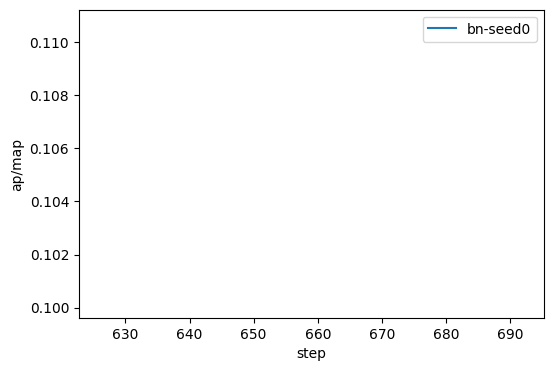

In [19]:
plot_metric("ap", "map")

In [20]:
final_ap()

,epoch,map,map_50,map_large,map_medium,map_small
run,,,,,,
bn-seed0,0,0.105419,0.216399,0.174078,0.116686,0.040699


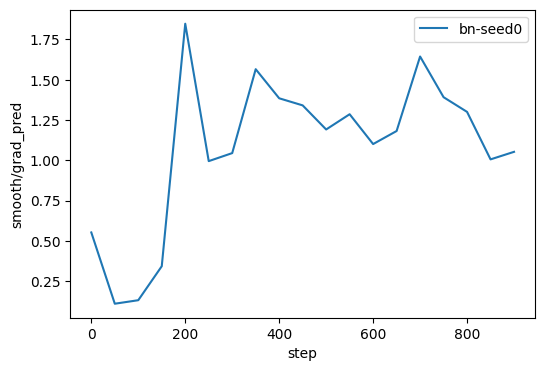

In [21]:
plot_metric("smooth", "grad_pred")

In [22]:
# Activation statistics

In [23]:
# Loss spread

In [24]:
# Gradient predictiveness and gradient norm

## Part 3: questions

Replace each placeholder with a short argument that rests on your plots. Give the numbers you use.

### 1. Keep or remove batch normalization

Decide whether to keep batch normalization in the FPN and box head. Answer from your plots. Compare the difference between `no_bn` and `bn` at seed 0 with the difference between the two `bn` seeds. Make this comparison for AP and for the smoothness measurements.

**Answer:** _Write your answer here._

### 2. Covariate shift or smoothness

Which explanation do your measurements support: reduced internal covariate shift, or a smoother loss landscape? For each measurement you rely on, say what it cannot show.

**Answer:** _Write your answer here._

## Submitting

Commit this notebook, with every cell output saved, under `assignments/assignment-2` in your clone of the class repository.

Add the URL of your Trackio Space to the folder's README. The Space must be public. Submit the GitHub URL for that folder, not the repository root.

The [assignment submission guide](/aiml-common/resources/environment/assignment-submission)
explains the remaining requirements, including how to set up your clone, add the TAs as collaborators, and create the README required in each assignment folder.